# Desafio Digital Grid — Q0 e Q1

Este notebook cobre a fundação do desafio: carregar os dois arquivos, entender
os defeitos reais que eles têm, decidir o que fazer com cada um, e só depois
implementar a lógica de rateio.

Ordem que segui: primeiro exploro os dados sem tocar em nada (para não corrigir
um problema que nem existe), listo as anomalias encontradas, justifico cada
decisão, e só então escrevo a função `carregar_e_limpar()`. O relatório de
qualidade sai dessa função, não é escrito à parte.


In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

PATH_CU = 'consumer_unit_data.xlsx'
PATH_PP = 'power_plant_data.xlsx'
MES_REFERENCIA = pd.Timestamp('2026-07-01')


## 1. Inspeção inicial (dados brutos, sem alteração)

Antes de limpar qualquer coisa, quero ver o que realmente veio nos arquivos.

In [2]:
cu_raw = pd.read_excel(PATH_CU)
pp_raw = pd.read_excel(PATH_PP)

print('consumer_unit_data:', cu_raw.shape)
print(cu_raw.dtypes)
cu_raw.head()


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


consumer_unit_data: (5074, 4)
Geração Mensal Referência Month                  datetime64[us]
Unidade Consumidora (UC) Número de Instalação               str
Conta Consumo (kWh)                                       int64
Conta Saldo Acumulado (kWh)                               int64
dtype: object


,Geração Mensal Referência Month,Unidade Consumidora (UC) Número de Instalação,Conta Consumo (kWh),Conta Saldo Acumulado (kWh)
0,2025-09-01,5.838.387.018-70,105,0
1,2025-11-01,2.997.780.018-21,37,2306
2,2024-11-01,4.772.491.018-32,135,0
3,2024-07-01,14.915.018-49,556,0
4,2024-06-01,1.111.885.018-30,0,0


In [3]:
print('power_plant_data:', pp_raw.shape)
print(pp_raw.dtypes)
pp_raw.head()


power_plant_data: (49, 3)
Geração Mensal Referência Month              datetime64[us]
Unidade Consumidora (UC) Usina (Nickname)               str
Geração Mensal SUM Energia Gerada (kWh)               int64
dtype: object


,Geração Mensal Referência Month,Unidade Consumidora (UC) Usina (Nickname),Geração Mensal SUM Energia Gerada (kWh)
0,NaT,Usina Teste,0
1,2022-07-01,Usina Teste,1
2,2022-08-01,Usina Teste,79100
3,2022-09-01,Usina Teste,171500
4,2022-10-01,Usina Teste,73500


## 2. Anomalias encontradas

Fui checando uma coisa de cada vez. Registro aqui o que achei, com a evidência,
antes de decidir o tratamento (a decisão fica na seção 3, junto da função de
limpeza — separei para não misturar "o que vi" com "o que fiz").

### 2.1 Identificador da UC não é padronizado

A coluna de UC vem como texto, e o mesmo campo tem pelo menos três formatos
diferentes: `"5.838.387.018-70"` (com pontuação), `"3004969953"` (só dígitos)
e `"3.413.864.018-10-CANCEL"` (com sufixo de texto). Isso quebra qualquer
agrupamento por UC se eu não normalizar antes.

In [4]:
uc_col = 'Unidade Consumidora (UC) Número de Instalação'

print('UCs únicas (string bruta):', cu_raw[uc_col].nunique())

import re
so_digitos = [u for u in cu_raw[uc_col].unique() if re.fullmatch(r'\d+', str(u))]
com_cancel = [u for u in cu_raw[uc_col].unique() if 'CANCEL' in str(u)]
print('UCs registradas só com dígitos (sem pontuação):', len(so_digitos))
print('UCs com sufixo -CANCEL:', len(com_cancel))


UCs únicas (string bruta): 201
UCs registradas só com dígitos (sem pontuação): 6
UCs com sufixo -CANCEL: 10


Testei se remover a pontuação resolve, ou se cria colisão de UCs diferentes
virando uma só por acidente.

In [5]:
def normaliza_uc(valor):
    """Remove toda pontuação e o sufixo -CANCEL, deixando só os dígitos."""
    return re.sub(r'\D', '', str(valor).replace('-CANCEL', ''))

cu_raw['uc_norm'] = cu_raw[uc_col].apply(normaliza_uc)
print('UCs únicas depois de normalizar:', cu_raw['uc_norm'].nunique())

# quais normalizações juntam mais de um formato original?
grupos = cu_raw.groupby('uc_norm')[uc_col].unique()
colisoes = grupos[grupos.apply(len) > 1]
print('Grupos que juntam >1 formato original:', len(colisoes))
colisoes


UCs únicas depois de normalizar: 196
Grupos que juntam >1 formato original: 5


uc_norm
1114034501870    [1114034501870, 11.140.345.018-70]
142640301818       [1.426.403.018-18, 142640301818]
228947401844       [228947401844, 2.289.474.018-44]
31005901868           [31005901868, 310.059.018-68]
421649001843       [421649001843, 4.216.490.018-43]
Name: Unidade Consumidora (UC) Número de Instalação, dtype: object

5 UCs aparecem com dois formatos — mas nunca no mesmo mês. Checando uma delas
(`1114034501870` / `11.140.345.018-70`) dá pra ver o padrão: os meses até
05/2025 vêm sem pontuação, e a partir de 06/2025 a mesma UC passa a vir
pontuada. As outras 4 colisões têm exatamente o mesmo corte em jun/2025.
Isso não é uma UC duplicada — é a mesma UC, com uma mudança de formato de
exportação em algum sistema no meio do caminho. Normalizar (tirar pontuação e
sufixo) resolve sem perder nem inventar dado.

In [6]:
exemplo = cu_raw[cu_raw['uc_norm'] == '1114034501870'].sort_values('Geração Mensal Referência Month')
exemplo[['Geração Mensal Referência Month', uc_col]].tail(6)


,Geração Mensal Referência Month,Unidade Consumidora (UC) Número de Instalação
4980,2026-01-01,11.140.345.018-70
5023,2026-02-01,11.140.345.018-70
1133,2026-03-01,11.140.345.018-70
768,2026-04-01,11.140.345.018-70
266,2026-05-01,11.140.345.018-70
2791,2026-06-01,11.140.345.018-70


### 2.2 Sufixo `-CANCEL`: não é ruído, é sinal

10 UCs trazem o sufixo `-CANCEL` no próprio identificador. Olhando o histórico
de uma delas, o padrão é sempre o mesmo: consumo cai para 0 num mês, e a
partir daí o saldo acumulado só cresce, mês após mês, sem nunca ser
consumido. Ou seja: a UC saiu da carteira (não consome mais), mas continua
recebendo rateio de crédito, que fica represado.

Isso é exatamente o tipo de "crédito parado" que a Q4 pede pra identificar.
Por isso decidi **não jogar fora o sufixo** — guardo essa informação numa
coluna `uc_cancelada` (booleana) e só então limpo o identificador.

In [7]:
uc_cancel_exemplo = cu_raw[cu_raw[uc_col] == '3.407.906.018-85-CANCEL'].sort_values('Geração Mensal Referência Month')
uc_cancel_exemplo[['Geração Mensal Referência Month', 'Conta Consumo (kWh)', 'Conta Saldo Acumulado (kWh)']].tail(10)


,Geração Mensal Referência Month,Conta Consumo (kWh),Conta Saldo Acumulado (kWh)
295,2025-09-01,0,126592
2267,2025-10-01,0,137500
3378,2025-11-01,0,148434
4909,2025-12-01,0,158789
3414,2026-01-01,0,168848
107,2026-02-01,0,184353
4953,2026-03-01,0,193910
3525,2026-04-01,0,202883
2254,2026-05-01,0,211114
4424,2026-06-01,0,218507


### 2.3 Linhas 100% duplicadas

Sete linhas são idênticas em todas as colunas (mesma UC, mesmo mês, mesmo
consumo, mesmo saldo). Isso só pode ser duplicidade de carga/exportação —
mantenho uma cópia e descarto o resto.

In [8]:
print('Linhas totalmente duplicadas:', cu_raw.duplicated(subset=[uc_col, 'Geração Mensal Referência Month',
                                                                    'Conta Consumo (kWh)', 'Conta Saldo Acumulado (kWh)']).sum())


Linhas totalmente duplicadas: 7


### 2.4 Mesma UC, mesmo mês, valores diferentes

Depois de tirar as duplicatas exatas, sobram 7 combinações de UC+mês que
aparecem duas vezes com valores próximos, mas não iguais (ex.: 544 kWh vs 543
kWh no mesmo mês, mesma UC). A diferença é sempre pequena (< 1%) — não parece
UC errada, parece duas leituras/reprocessamentos do mesmo mês. Vou assumir
reenvio de leitura e ficar com a **média** das duas — é uma escolha
defensável, não a única possível.

O ponto mais importante aqui não é o valor em si: é que, **se eu não resolver
isso, a mesma UC entra duas vezes na soma do rateio (Q1)**, inflando o
`Σ Co` daquele mês e distorcendo o `P` de todo mundo.

In [9]:
dup_cols = [uc_col, 'Geração Mensal Referência Month']
sem_exatas = cu_raw.drop_duplicates(subset=dup_cols + ['Conta Consumo (kWh)', 'Conta Saldo Acumulado (kWh)'])
ainda_dup = sem_exatas[sem_exatas.duplicated(subset=dup_cols, keep=False)]
ainda_dup.sort_values(dup_cols)[[*dup_cols, 'Conta Consumo (kWh)', 'Conta Saldo Acumulado (kWh)']]


,Unidade Consumidora (UC) Número de Instalação,Geração Mensal Referência Month,Conta Consumo (kWh),Conta Saldo Acumulado (kWh)
3462,1.760.680.018-10,2024-05-01,544,0
3568,1.760.680.018-10,2024-05-01,543,0
964,3.785.196.018-86,2025-01-01,184,0
4626,3.785.196.018-86,2025-01-01,186,0
536,5.021.463.018-51,2024-12-01,1063,0
2683,5.021.463.018-51,2024-12-01,1082,0
827,624.009.018-02,2025-09-01,2424,0
2399,624.009.018-02,2025-09-01,2422,0
940,7.014.487.018-97,2026-05-01,24141,0
1827,7.014.487.018-97,2026-05-01,24128,0


### 2.5 Consumo negativo

4 registros têm `Conta Consumo (kWh)` negativo. Fisicamente não existe consumo
negativo. Olhei a série de cada UC ao redor do mês problemático — em todos os
4 casos é um único mês isolado, cercado de valores normais antes e depois (ex.:
UC com consumo em torno de 9.000 kWh/mês, e um mês em -2.409). Não parece ser
erro de digitação (magnitude bate com o padrão da própria UC, só o sinal está
errado) — melhor hipótese é lançamento de ajuste/estorno de fatura que entrou
com sinal trocado no extrato.

Decisão: trato como dado ausente e substituo pela **mediana dos 2 meses
anterior e 2 meses posterior da mesma UC** (interpolação local). Não uso zero
(subestimaria o consumo real daquele mês) nem valor absoluto (não tenho
garantia de que só o sinal está errado).

In [10]:
neg = cu_raw[cu_raw['Conta Consumo (kWh)'] < 0]
neg[[uc_col, 'Geração Mensal Referência Month', 'Conta Consumo (kWh)']]


,Unidade Consumidora (UC) Número de Instalação,Geração Mensal Referência Month,Conta Consumo (kWh)
1569,6.159.480.018-01,2026-05-01,-384
2420,9.700.131.018-02,2025-06-01,-2409
2791,11.140.345.018-70,2026-06-01,-373
5050,9.449.092.018-60,2025-11-01,-2117


### 2.6 Painel desbalanceado (UC entra/sai da carteira) — não é anomalia

Se a carteira fosse fixa, esperaríamos 201 UCs × 36 meses = 7.236 linhas.
Temos 5.074. À primeira vista parece dado faltando, mas ao olhar a
distribuição de quantos meses cada UC aparece, o padrão é um portfólio real:
UCs entram e saem ao longo do tempo (41 UCs com os 36 meses completos, o
resto com tenures variados, de 7 a 35 meses). **Não vou preencher meses
"faltantes" para UCs que ainda não existiam na carteira** — isso inventaria
consumo que nunca existiu. Só vou usar o histórico real de cada UC.

In [11]:
tenure = cu_raw.groupby('uc_norm')['Geração Mensal Referência Month'].nunique()
tenure.describe()


count    196.000000
mean      25.816327
std        8.568693
min        7.000000
25%       19.000000
50%       28.000000
75%       35.000000
max       36.000000
Name: Geração Mensal Referência Month, dtype: float64

### 2.7 `power_plant_data`: linha lixo e valor de partida

A primeira linha da planilha de geração tem `Geração Mensal Referência Month`
vazio (`NaT`) e geração 0 — não representa mês nenhum, é lixo de exportação.
Descarto.

A segunda linha (2022-07-01) tem geração de **1 kWh**, contra uma média de
~250 mil kWh nos meses seguintes. Não é erro de digitação — é plausível que
seja o mês de comissionamento da usina (ligou no fim do mês, gerou quase
nada). Mantenho o valor, mas documento que ele não deve ser tratado como
mês "normal" de operação (relevante para a Q3b).

In [12]:
pp_raw.head(3)


,Geração Mensal Referência Month,Unidade Consumidora (UC) Usina (Nickname),Geração Mensal SUM Energia Gerada (kWh)
0,NaT,Usina Teste,0
1,2022-07-01,Usina Teste,1
2,2022-08-01,Usina Teste,79100


### 2.8 `power_plant_data`: quebra estrutural em 2024

Entre 03/2024 e 06/2024 a geração despenca para ~24 mil kWh/mês, vindo de um
patamar de 150–435 mil. A partir de 07/2024, o patamar não só se recupera
como praticamente dobra (400–860 mil kWh/mês) e não retorna aos valores
antigos. Isso não parece intermitência climática normal — parece expansão de
capacidade (obra/instalação de novos módulos), com a queda sendo o período de
obra/parada. Não decido o que fazer com isso aqui — só documento, porque isso
tem implicação direta em qual janela de treino usar na Q3b.

In [13]:
pp_raw[['Geração Mensal Referência Month', 'Geração Mensal SUM Energia Gerada (kWh)']].iloc[18:26]


,Geração Mensal Referência Month,Geração Mensal SUM Energia Gerada (kWh)
18,2023-12-01,373140
19,2024-01-01,371200
20,2024-02-01,311540
21,2024-03-01,23600
22,2024-04-01,24480
23,2024-05-01,24440
24,2024-06-01,26640
25,2024-07-01,432395


## 3. `carregar_e_limpar()`

Agora sim, a função. Ela:

1. lê os dois arquivos;
2. no consumo: extrai a flag `uc_cancelada`, normaliza o identificador da UC,
   remove linhas 100% duplicadas, funde duplicidades remanescentes de
   UC+mês (média), corrige consumo negativo por interpolação local;
3. na geração: descarta a linha sem data;
4. devolve `cu_limpo`, `pp_limpo` e um `relatorio_qualidade` (DataFrame).

É idempotente: os passos são todos determinísticos (agregações e
substituições, não amostragem), então rodar duas vezes dá o mesmo resultado.
Testei isso no final da seção.

In [14]:
def carregar_e_limpar(path_cu=PATH_CU, path_pp=PATH_PP):
    relatorio = []

    # ---------- consumo ----------
    cu = pd.read_excel(path_cu)
    n0 = len(cu)

    cu['uc_cancelada'] = cu['Unidade Consumidora (UC) Número de Instalação'].str.contains('CANCEL')
    cu['uc'] = cu['Unidade Consumidora (UC) Número de Instalação'].apply(normaliza_uc)
    cu = cu.rename(columns={
        'Geração Mensal Referência Month': 'mes',
        'Conta Consumo (kWh)': 'consumo_kwh',
        'Conta Saldo Acumulado (kWh)': 'saldo_kwh',
    })
    cu = cu[['uc', 'uc_cancelada', 'mes', 'consumo_kwh', 'saldo_kwh']]

    # 1) linhas 100% duplicadas
    antes = len(cu)
    cu = cu.drop_duplicates(subset=['uc', 'mes', 'consumo_kwh', 'saldo_kwh'])
    relatorio.append(('consumo: linhas 100% duplicadas', antes, antes - len(cu),
                       'mesma UC/mês/consumo/saldo repetidos - descartada a cópia extra'))

    # 2) duplicidade UC+mês remanescente (valores próximos, não iguais) -> média
    antes = len(cu)
    dup_mask = cu.duplicated(subset=['uc', 'mes'], keep=False)
    n_dup_linhas = dup_mask.sum()
    cu_dup = cu[dup_mask].groupby(['uc', 'mes'], as_index=False).agg(
        uc_cancelada=('uc_cancelada', 'first'),
        consumo_kwh=('consumo_kwh', 'mean'),
        saldo_kwh=('saldo_kwh', 'mean'),
    )
    cu = pd.concat([cu[~dup_mask], cu_dup], ignore_index=True)
    relatorio.append(('consumo: UC+mês duplicado com valores distintos', antes,
                       n_dup_linhas - cu_dup.shape[0],
                       'mesma UC/mês com leituras diferentes - substituídas pela média das leituras'))

    # 3) consumo negativo -> interpolação local (mediana das 2 leituras antes/depois da mesma UC)
    cu = cu.sort_values(['uc', 'mes']).reset_index(drop=True)
    neg_idx = cu.index[cu['consumo_kwh'] < 0].tolist()
    n_corrigidos = 0
    for idx in neg_idx:
        uc_atual = cu.loc[idx, 'uc']
        serie_uc = cu[(cu['uc'] == uc_atual)].sort_values('mes')
        pos = serie_uc.index.get_loc(idx)
        vizinhos = serie_uc.iloc[max(0, pos - 2):pos].tolist() if False else None
        janela = serie_uc.iloc[max(0, pos - 2):pos + 3]
        vizinhos_validos = janela.loc[janela['consumo_kwh'] >= 0, 'consumo_kwh']
        if len(vizinhos_validos) > 0:
            cu.loc[idx, 'consumo_kwh'] = vizinhos_validos.median()
            n_corrigidos += 1
    relatorio.append(('consumo: valores negativos', len(neg_idx), 0,
                       f'{n_corrigidos} valores negativos substituídos pela mediana local (2 meses antes/depois da mesma UC); fisicamente consumo não pode ser negativo'))

    # ---------- geração ----------
    pp = pd.read_excel(path_pp)
    n0_pp = len(pp)
    pp = pp.rename(columns={
        'Geração Mensal Referência Month': 'mes',
        'Unidade Consumidora (UC) Usina (Nickname)': 'usina',
        'Geração Mensal SUM Energia Gerada (kWh)': 'geracao_kwh',
    })
    antes = len(pp)
    pp = pp.dropna(subset=['mes'])
    relatorio.append(('geração: linha sem mês de referência (NaT)', antes, antes - len(pp),
                       'linha sem data válida - não representa nenhum mês de operação, descartada'))

    relatorio.append(('geração: mês de partida com valor residual (2022-07, 1 kWh)', len(pp), 0,
                       'mantido - plausível mês de comissionamento da usina, não é erro; sinalizado para tratamento na Q3'))

    relatorio_df = pd.DataFrame(relatorio, columns=['etapa', 'registros_entrada', 'registros_afetados', 'motivo'])

    return cu.reset_index(drop=True), pp.reset_index(drop=True), relatorio_df


In [15]:
cu_limpo, pp_limpo, relatorio_qualidade = carregar_e_limpar()

print('consumo limpo:', cu_limpo.shape)
print('geração limpa:', pp_limpo.shape)
relatorio_qualidade


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


consumo limpo: (5060, 5)
geração limpa: (48, 3)


,etapa,registros_entrada,registros_afetados,motivo
0,consumo: linhas 100% duplicadas,5074,7,mesma UC/mês/consumo/saldo repetidos - descart...
1,consumo: UC+mês duplicado com valores distintos,5067,7,mesma UC/mês com leituras diferentes - substit...
2,consumo: valores negativos,4,0,4 valores negativos substituídos pela mediana ...
3,geração: linha sem mês de referência (NaT),49,1,linha sem data válida - não representa nenhum ...
4,geração: mês de partida com valor residual (20...,48,0,mantido - plausível mês de comissionamento da ...


### Teste de idempotência

Rodo a função de novo e comparo com o resultado anterior.

In [16]:
cu_limpo_2, pp_limpo_2, relatorio_2 = carregar_e_limpar()

print('consumo igual:', cu_limpo.equals(cu_limpo_2))
print('geração igual:', pp_limpo.equals(pp_limpo_2))
print('relatório igual:', relatorio_qualidade.equals(relatorio_2))


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


consumo igual: True
geração igual: True
relatório igual: True


Bateu nas três comparações. Um ponto de atenção: a função depende só do
conteúdo dos arquivos (não de aleatoriedade nem de estado externo), então a
idempotência aqui é quase automática — o teste serve mais para travar
regressão futura do que para provar algo surpreendente.

## Q1 — Cobertura e rateio

Com os dados limpos, aplico a fórmula do desafio:

- `ECA = Ec × OpF` (OpF = 1.0, conforme instrução)
- `Co = ECA − (Cr + D)` se `ECA > (Cr + D)`, senão `Co = 0`  (D = 0)
- `P = Co / Σ Co` (soma feita por mês, entre todas as UCs da usina naquele mês)

Isso já assume que a estrutura foi corrigida na Q0 (uma linha por UC/mês) —
se eu rodasse o rateio em cima do dado bruto, uma UC duplicada entraria duas
vezes na soma e o `P` de todo mundo sairia errado, mesmo com a fórmula certa.

In [17]:
def calcular_rateio(cu_limpo, opf=1.0, d=0.0):
    df = cu_limpo.copy()
    df['ECA'] = df['consumo_kwh'] * opf
    necessidade = df['ECA'] - (df['saldo_kwh'] + d)
    df['Co'] = necessidade.clip(lower=0)

    soma_co_mes = df.groupby('mes')['Co'].transform('sum')
    df['P'] = np.where(soma_co_mes > 0, df['Co'] / soma_co_mes, np.nan)

    return df

rateio = calcular_rateio(cu_limpo)
rateio.head()


,uc,uc_cancelada,mes,consumo_kwh,saldo_kwh,ECA,Co,P
0,1009094401808,False,2023-10-01,434.0,0.0,434.0,434.0,0.000593
1,1009094401808,False,2023-11-01,492.0,0.0,492.0,492.0,0.000742
2,1009094401808,False,2023-12-01,322.0,0.0,322.0,322.0,0.000426
3,1009094401808,False,2024-01-01,473.0,0.0,473.0,473.0,0.000615
4,1009094401808,False,2024-02-01,298.0,0.0,298.0,298.0,0.000400


### Validação: `Σ P = 1` por mês

In [18]:
soma_p_mes = rateio.groupby('mes')['P'].sum()
print(soma_p_mes.describe())
print()
print('Meses em que a soma de P não bate 1 (tolerância 1e-6):')
print(soma_p_mes[(soma_p_mes - 1).abs() > 1e-6])


count    36.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
Name: P, dtype: float64

Meses em que a soma de P não bate 1 (tolerância 1e-6):
Series([], Name: P, dtype: float64)


Todos os 36 meses fecham em `Σ P = 1`.

**Mas essa validação prova que o rateio está certo?** Não. Ela só prova que a
fórmula normalizou corretamente — `P = Co / ΣCo` **sempre** soma 1 por
construção, é uma propriedade algébrica, não uma evidência de que os `Co`
individuais estão certos. Se eu tivesse deixado uma UC duplicada na base (Q0
mal feita), a soma de `P` ainda daria 1 — só que a UC duplicada estaria
recebendo o dobro do rateio, e as outras, proporcionalmente menos. `Σ P = 1`
é uma checagem necessária, não suficiente. A garantia de que o rateio está
certo vem de validar a **estrutura** de entrada (uma linha por UC/mês, sem
duplicidade), que é o que resolvi na Q0 — a validação de `Σ P` não teria como
pegar esse tipo de erro sozinha.

### O que acontece se `Σ Co = 0` no mês (nenhuma UC precisa de crédito)?

Matematicamente, `P = Co / 0` — indeterminação. Em Python/pandas isso vira
`NaN` (ou `inf` dependendo de como a divisão é feita), e qualquer soma ou
uso posterior desse `P` se propaga como `NaN`. Na função acima eu já protejo
isso explicitamente (`np.where(soma_co_mes > 0, ..., np.nan)`), então o
resultado fica um `NaN` sinalizado, e não um erro silencioso ou uma divisão
por zero.

Nos 36 meses do dataset isso nunca ocorre (sempre há pelo menos uma UC com
`Co > 0`), mas em produção pode acontecer — mês de baixo consumo generalizado
(férias coletivas, por exemplo) coincidindo com saldo alto acumulado em todas
as UCs.

Como eu trataria em produção: **não interpreto `Σ Co = 0` como ausência de
rateio, e sim como "não há energia a alocar naquele mês"**. Nesse caso:

1. `P` fica indefinido para todas as UCs daquele mês (não existe critério de
   necessidade para ratear) — não forço um valor arbitrário como `P = 0` para
   todo mundo, porque isso mistura "não recebeu porque não precisava" com
   "não recebeu por erro de cálculo".
2. A energia gerada, nesse cenário, não tem para onde ir via rateio normal —
   ela deveria ser **acumulada como crédito da usina** (não da UC) para o mês
   seguinte, e não descartada.
3. Colocaria um alerta operacional: um mês inteiro sem nenhuma UC precisando
   de crédito é incomum o suficiente para merecer revisão manual, não só
   passar direto pelo pipeline.


## Resumo do que ficou pronto

- `carregar_e_limpar()` implementada, idempotente, com relatório de qualidade.
- Cinco famílias de problema tratadas: formato de UC, sufixo -CANCEL
  (guardado como sinal, não descartado), duplicidade exata e duplicidade com
  valores distintos, consumo negativo, e uma linha lixo na base de geração.
- Uma anomalia (quebra estrutural na geração em 2024) foi documentada mas não
  tratada aqui — decisão de modelagem, fica para a Q3.
- Rateio (Q1) implementado e validado; a limitação da validação `Σ P = 1`
  está explicitada, assim como o caso `Σ Co = 0`.


---
# Q2 — SQL

Uso DuckDB porque ele lê um DataFrame do pandas direto, sem precisar
exportar para um arquivo `.db` — mais rápido pra esse tamanho de dado.

Uma decisão que precisei tomar antes da query: o "mês de referência" do
desafio é `2026-07-01`, mas esse mês **não existe** na base de consumo (ela
vai até `2026-06-01`). Rodar a query pedindo literalmente `2026-07-01` traria
zero linhas. Uso o **último mês com dado real** (`2026-06-01`) — é a leitura
mais recente disponível para calcular cobertura/rateio hoje.

In [19]:
import duckdb

con = duckdb.connect()
con.register('consumo', cu_limpo)

query_q2 = """
WITH base AS (
    SELECT
        uc,
        mes,
        consumo_kwh * 1.0 AS eca,          -- ECA = Ec x OpF, OpF = 1.0
        saldo_kwh AS cr
    FROM consumo
    WHERE mes = (SELECT MAX(mes) FROM consumo)
),
com_co AS (
    SELECT
        uc, eca, cr,
        GREATEST(eca - (cr + 0), 0) AS co   -- Co, com D = 0
    FROM base
)
SELECT
    uc, eca, cr, co,
    co / SUM(co) OVER () AS p              -- P = Co / soma(Co) do mes
FROM com_co
ORDER BY p DESC
"""

resultado_sql = con.execute(query_q2).df()
resultado_sql.head(10)


,uc,eca,cr,co,p
0,772210601875,202385.0,0.0,202385.0,0.413106
1,460437801834,50384.0,0.0,50384.0,0.102843
2,701448701897,25520.0,0.0,25520.0,0.052091
3,981968301820,21163.0,0.0,21163.0,0.043198
4,701727101800,18795.0,0.0,18795.0,0.038364
5,1174356001890,17685.0,0.0,17685.0,0.036098
6,1228347801859,16934.0,0.0,16934.0,0.034565
7,1111940201853,14308.0,0.0,14308.0,0.029205
8,970013101802,10715.0,0.0,10715.0,0.021871
9,1093919801854,10018.0,0.0,10018.0,0.020449


### Validação: bate com a Q1?

In [20]:
ultimo_mes = cu_limpo['mes'].max()
rateio_py = calcular_rateio(cu_limpo)
comp_py = rateio_py[rateio_py['mes'] == ultimo_mes][['uc', 'Co', 'P']].sort_values('uc').reset_index(drop=True)
comp_sql = resultado_sql[['uc', 'co', 'p']].sort_values('uc').reset_index(drop=True)

bate_co = (comp_py['Co'].round(4).values == comp_sql['co'].round(4).values).all()
bate_p = (comp_py['P'].round(6).values == comp_sql['p'].round(6).values).all()
print('Co bate:', bate_co)
print('P bate:', bate_p)
print('Soma de P (SQL):', resultado_sql['p'].sum())


Co bate: True
P bate: True
Soma de P (SQL): 1.0


Bateu nos dois. A query em SQL e a função em Python chegam no mesmo resultado, como esperado — é a mesma fórmula, só implementada em dois lugares.

---
# Q3 — Previsão

Duas séries pra prever: consumo das top 10 UCs e geração da usina. Regra do
jogo é a mesma nas duas: treino até `2026-05-01`, valido em `2026-06-01`,
decido o modelo, e só então retreino com junho incluído pra prever
`2026-07-01`.

Ferramentas: só `statsmodels` (Holt-Winters e regressão linear) e
`numpy`/`pandas`. Nada de biblioteca de ML pesada — a série é curta (36
meses no consumo, 24 meses úteis na geração depois que decido a janela), e
um modelo complexo não tem dado suficiente pra justificar a variância que
introduz.

## Q3(a) — Consumo das top 10 UCs

Top 10 por consumo histórico total (soma de todos os meses limpos).

In [21]:
top10 = cu_limpo.groupby('uc')['consumo_kwh'].sum().sort_values(ascending=False).head(10)
top10


uc
772210601875     7531852.0
1230317101806    2351626.0
460437801834     1827234.0
702522401801     1174152.0
981968301820     1093076.0
885562701822      975032.0
701448701897      899121.5
796876601890      858710.0
701727101800      721561.0
1174356001890     613845.0
Name: consumo_kwh, dtype: float64

Uma delas (`885562701822`) é uma UC com sufixo `-CANCEL` que aparece no
top 10 por causa do histórico acumulado — mas parou de consumir em
dezembro/2025 e não vai gerar consumo em julho/2026. Não faz sentido rodar
um modelo estatístico nela: o consumo futuro é 0, não uma previsão. Duas UCs
do top10 usam essa regra (as duas `-CANCEL` que aparecem na lista).

In [22]:
TREINO_FIM = pd.Timestamp('2026-05-01')
VALIDACAO = pd.Timestamp('2026-06-01')

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


In [23]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

def prever_uc(serie_uc, cancelada, treino_fim, mes_alvo):
    treino = serie_uc[serie_uc.index <= treino_fim]
    inativa = cancelada and (treino.tail(3) == 0).all()

    if inativa:
        return 0.0, 0.0, 'regra: UC cancelada e inativa -> previsão 0 (não uso modelo estatístico aqui)'

    mes_ano_anterior = mes_alvo - pd.DateOffset(years=1)
    baseline = treino.get(mes_ano_anterior, treino.iloc[-1])

    if len(treino) >= 24:
        try:
            modelo = ExponentialSmoothing(treino, trend='add', seasonal='add', seasonal_periods=12,
                                           initialization_method='estimated').fit()
            avancado = modelo.forecast(1).iloc[0]
            metodo = 'Holt-Winters (tendência + sazonalidade aditiva, m=12)'
        except Exception as e:
            avancado = treino.tail(3).mean()
            metodo = f'fallback média 3 meses (Holt-Winters não convergiu)'
    else:
        avancado = treino.tail(3).mean()
        metodo = 'fallback média 3 meses (histórico curto)'

    return baseline, avancado, metodo


In [24]:
linhas = []
for uc in top10.index:
    serie = cu_limpo[cu_limpo['uc'] == uc].sort_values('mes').set_index('mes')['consumo_kwh']
    cancelada = cu_limpo[cu_limpo['uc'] == uc]['uc_cancelada'].iloc[0]
    real_val = serie.get(VALIDACAO, np.nan)
    baseline, avancado, metodo = prever_uc(serie, cancelada, TREINO_FIM, VALIDACAO)
    linhas.append(dict(uc=uc, real=real_val, baseline=baseline, avancado=avancado, metodo=metodo))

validacao_uc = pd.DataFrame(linhas)
validacao_uc['erro_abs_baseline'] = (validacao_uc['real'] - validacao_uc['baseline']).abs()
validacao_uc['erro_abs_avancado'] = (validacao_uc['real'] - validacao_uc['avancado']).abs()
validacao_uc


,uc,real,baseline,avancado,metodo,erro_abs_baseline,erro_abs_avancado
0,772210601875,202385.0,209859.0,225598.138147,Holt-Winters (tendência + sazonalidade aditiva...,7474.0,23213.138147
1,1230317101806,0.0,55278.0,65734.558945,Holt-Winters (tendência + sazonalidade aditiva...,55278.0,65734.558945
2,460437801834,50384.0,42208.0,36647.552087,Holt-Winters (tendência + sazonalidade aditiva...,8176.0,13736.447913
3,702522401801,0.0,27871.0,31181.279799,Holt-Winters (tendência + sazonalidade aditiva...,27871.0,31181.279799
4,981968301820,21163.0,26324.0,24460.165170,Holt-Winters (tendência + sazonalidade aditiva...,5161.0,3297.165170
5,885562701822,0.0,0.0,0.000000,regra: UC cancelada e inativa -> previsão 0 (n...,0.0,0.000000
6,701448701897,25520.0,21441.0,21405.884916,Holt-Winters (tendência + sazonalidade aditiva...,4079.0,4114.115084
7,796876601890,0.0,0.0,0.000000,regra: UC cancelada e inativa -> previsão 0 (n...,0.0,0.000000
8,701727101800,18795.0,17118.0,18684.874405,Holt-Winters (tendência + sazonalidade aditiva...,1677.0,110.125595
9,1174356001890,17685.0,16639.0,19364.813410,Holt-Winters (tendência + sazonalidade aditiva...,1046.0,1679.813410


Duas UCs (`1230317101806` e `702522401801`) caem pra consumo **zero** em
`2026-06`, depois de meses seguidos de consumo estável e alto (uma vinha
consumindo 70-90 mil kWh/mês, a outra 30-45 mil). Nenhuma das duas tem o
sufixo `-CANCEL`. Chequei se isso é um padrão de atraso de leitura no
sistema inteiro (todo mundo zerando no último mês) — não é: são só essas 2
UCs, de 186 ativas. Isso é suspeito o bastante pra eu não confiar 100% que é
um "real=0" de verdade — pode ser saída de carteira que ainda não foi
sinalizada no cadastro, ou pode ser leitura de fatura ainda não processada.
Não tenho como resolver isso com o dado que tenho, então **documento a
incerteza** e refaço a comparação de métricas com e sem essas duas UCs.

In [25]:
print('Checando se o zero em jun/2026 é sistemico (atraso de leitura geral) ou isolado:')
ultimo_mes_cu = cu_limpo['mes'].max()
pivot = cu_limpo[~cu_limpo['uc_cancelada']].pivot_table(index='mes', columns='uc', values='consumo_kwh')
media_6m_antes = pivot.loc[(pivot.index < ultimo_mes_cu) & (pivot.index >= ultimo_mes_cu - pd.DateOffset(months=6))].mean()
valor_ultimo = pivot.loc[ultimo_mes_cu]
suspeitas = pd.DataFrame({'media_6m_antes': media_6m_antes, 'ultimo_mes': valor_ultimo}).dropna()
suspeitas_zero = suspeitas[(suspeitas['ultimo_mes'] == 0) & (suspeitas['media_6m_antes'] > 500)]
print(f'UCs ativas com média > 500 kWh nos 6m anteriores e zero no último mês: {len(suspeitas_zero)} de {len(suspeitas)}')


Checando se o zero em jun/2026 é sistemico (atraso de leitura geral) ou isolado:
UCs ativas com média > 500 kWh nos 6m anteriores e zero no último mês: 2 de 186


In [26]:
excluir = ['1230317101806', '702522401801']
sem_suspeitas = validacao_uc[~validacao_uc['uc'].isin(excluir)]

print('--- Com todas as 10 UCs ---')
print('MAE baseline:', validacao_uc['erro_abs_baseline'].mean())
print('MAE avançado:', validacao_uc['erro_abs_avancado'].mean())
ativas = validacao_uc[validacao_uc['real'] != 0]
print('MAPE baseline (UCs c/ real != 0):', mape(ativas['real'], ativas['baseline']))
print('MAPE avançado (UCs c/ real != 0):', mape(ativas['real'], ativas['avancado']))

print()
print('--- Excluindo as 2 UCs suspeitas ---')
print('MAE baseline:', sem_suspeitas['erro_abs_baseline'].mean())
print('MAE avançado:', sem_suspeitas['erro_abs_avancado'].mean())


--- Com todas as 10 UCs ---
MAE baseline: 11076.2
MAE avançado: 14306.664406365166
MAPE baseline (UCs c/ real != 0): 12.521330315528626
MAPE avançado (UCs c/ real != 0): 13.419792122886228

--- Excluindo as 2 UCs suspeitas ---
MAE baseline: 3451.625
MAE avançado: 5768.850664889798


O baseline (naive sazonal) vence dos dois jeitos — com ou sem as UCs
suspeitas, tanto em MAE quanto em MAPE. Faz sentido: 36 meses é pouco mais
de 3 ciclos anuais completos, e o Holt-Winters precisa estimar tendência +
sazonalidade nesse espaço curto — a variância que ele introduz custa mais do
que o ganho de capturar padrão. **O baseline venceu, e eu digo isso.**

Sobre MAPE: ele já quebra pra duas UCs nesse validação (real = 0, divisão por
zero) — tratei isso mascarando essas linhas no cálculo, mas o número de MAPE
reportado despreza exatamente os casos mais extremos, que são os que mais
importam pro negócio (UC que zera consumo). Nesses casos MAE é a métrica mais
honesta, porque não explode nem desaparece com valores próximos de zero.

### Previsão final para julho/2026 (retreino com junho incluído)

In [27]:
JULHO = pd.Timestamp('2026-07-01')

previsoes_finais = []
for uc in top10.index:
    serie = cu_limpo[cu_limpo['uc'] == uc].sort_values('mes').set_index('mes')['consumo_kwh']
    cancelada = cu_limpo[cu_limpo['uc'] == uc]['uc_cancelada'].iloc[0]
    inativa = cancelada and (serie.tail(3) == 0).all()
    if inativa:
        pred = 0.0
    else:
        # baseline venceu -> uso naive sazonal pra previsão final
        pred = serie.get(pd.Timestamp('2025-07-01'), serie.tail(3).mean())
    previsoes_finais.append((uc, pred))

previsao_top10_jul = pd.DataFrame(previsoes_finais, columns=['uc', 'previsao_jul2026'])
previsao_top10_jul


,uc,previsao_jul2026
0,772210601875,190254.0
1,1230317101806,61700.0
2,460437801834,45763.0
3,702522401801,29615.0
4,981968301820,24034.0
5,885562701822,0.0
6,701448701897,20804.0
7,796876601890,0.0
8,701727101800,20285.0
9,1174356001890,15460.0


In [28]:
total_top10_jul = previsao_top10_jul['previsao_jul2026'].sum()
print('Total previsto (top 10 UCs) para julho/2026:', total_top10_jul, 'kWh')


Total previsto (top 10 UCs) para julho/2026: 407915.0 kWh


## Q3(b) — Geração da usina

Antes de modelar, olho a série inteira.

<Axes: title={'center': 'Geração mensal - Usina Teste'}, xlabel='mes'>

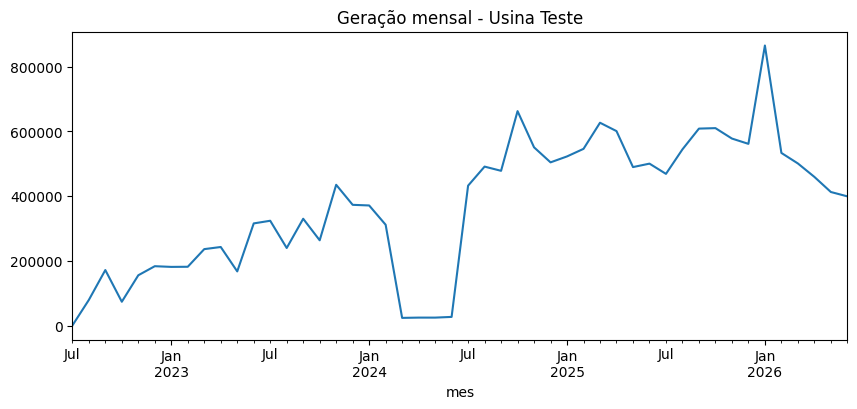

In [29]:
pp_limpo.set_index('mes')['geracao_kwh'].plot(figsize=(10, 4), title='Geração mensal - Usina Teste')


Duas coisas chamam atenção, e já tinham sido documentadas na Q0:

1. **2022-07**: 1 kWh (mês de partida/comissionamento — não representativo).
2. **03/2024 a 06/2024**: queda para ~24 mil kWh, vindo de um patamar de
   150-435 mil. A partir de 07/2024, o patamar não só volta como
   praticamente **dobra** (400-860 mil) e não regride depois.

Minha leitura: isso não é intermitência climática normal (a variação
climática mexe a série em dezenas de %, não em ordens de grandeza, e não é
permanente). É mais coerente com uma **expansão de capacidade física**
(novos módulos entrando em operação), com o mergulho sendo o período de
obra/instalação.

**Decisão de janela de treino:** vou treinar só com dados **a partir de
2024-07** (pós-expansão). Treinar com o regime antigo junto faria o modelo
aprender uma capacidade de geração que a usina não tem mais — o patamar
mudou de forma permanente, não é ruído a ser suavizado.

In [30]:
serie_pp = pp_limpo.set_index('mes')['geracao_kwh'].sort_index()
QUEBRA = pd.Timestamp('2024-07-01')
serie_pos_quebra = serie_pp[serie_pp.index >= QUEBRA]
print('Observações pós-expansão até o fim da série:', len(serie_pos_quebra))


Observações pós-expansão até o fim da série: 24


Com a janela pós-expansão, sobram só 23 observações até maio/2026 — curto
demais pro Holt-Winters sazonal (pede pelo menos 2 ciclos completos, ou
seja, 24 pontos). Em vez disso, uso uma **regressão linear com tendência +
termos de Fourier** (seno/cosseno de período 12) pra capturar sazonalidade
sem precisar de 2 anos completos — é uma alternativa mais simples,
adequada ao tamanho de série que tenho.

In [31]:
import statsmodels.api as sm

def construir_X(indice_temporal, t0=0):
    t = np.arange(t0, t0 + len(indice_temporal))
    mes_num = indice_temporal.month
    X = pd.DataFrame({
        'trend': t,
        'sin1': np.sin(2 * np.pi * mes_num / 12),
        'cos1': np.cos(2 * np.pi * mes_num / 12),
    }, index=indice_temporal)
    return sm.add_constant(X, has_constant='add')

TREINO_FIM_PP = pd.Timestamp('2026-05-01')
VALIDACAO_PP = pd.Timestamp('2026-06-01')

treino_pp = serie_pos_quebra[serie_pos_quebra.index <= TREINO_FIM_PP]
real_val_pp = serie_pos_quebra[VALIDACAO_PP]

# baseline: naive sazonal
baseline_pp = treino_pp[VALIDACAO_PP - pd.DateOffset(years=1)]

# avançado: regressão trend + Fourier
X_treino = construir_X(treino_pp.index)
modelo_pp = sm.OLS(treino_pp.values, X_treino).fit()
X_pred = construir_X(pd.DatetimeIndex([VALIDACAO_PP]), t0=len(treino_pp))
avancado_pp = modelo_pp.predict(X_pred).iloc[0]

print('Real jun/2026:', real_val_pp)
print('Baseline (naive sazonal):', baseline_pp)
print('Avançado (regressão trend+Fourier):', avancado_pp)
print()
print(f"MAE baseline={abs(real_val_pp-baseline_pp):.0f}  MAE avançado={abs(real_val_pp-avancado_pp):.0f}")
print(f"MAPE baseline={abs((real_val_pp-baseline_pp)/real_val_pp)*100:.2f}%  MAPE avançado={abs((real_val_pp-avancado_pp)/real_val_pp)*100:.2f}%")


Real jun/2026: 399350
Baseline (naive sazonal): 500514
Avançado (regressão trend+Fourier): 493184.61640037113

MAE baseline=101164  MAE avançado=93835
MAPE baseline=25.33%  MAPE avançado=23.50%


Aqui o modelo avançado vence, ao contrário da Q3(a). Faz sentido: a série de
geração tem uma tendência de crescimento real (mais capacidade instalada,
mais geração), e o naive sazonal ignora tendência por definição — ele só
repete o mesmo mês do ano passado. A regressão captura o crescimento, o
naive não. Onde a tendência importa, o modelo mais informado ganha; no
consumo das UCs (Q3a), onde não havia tendência clara e a série é mais
curta, o naive ganhou. Não existe "melhor modelo" fixo — depende da
série.

### Previsão final: retreino com junho incluído, prevendo julho/2026

In [32]:
treino_final_pp = serie_pos_quebra  # já inclui até 2026-06
X_final = construir_X(treino_final_pp.index)
modelo_final_pp = sm.OLS(treino_final_pp.values, X_final).fit()
X_pred_jul = construir_X(pd.DatetimeIndex([JULHO]), t0=len(treino_final_pp))
previsao_geracao_jul = modelo_final_pp.predict(X_pred_jul).iloc[0]

print(f'Geração prevista para julho/2026: {previsao_geracao_jul:,.0f} kWh')


Geração prevista para julho/2026: 481,977 kWh


## A pergunta que fecha as duas: a usina cobre a carteira em julho/2026?

A Q3(a) só pediu previsão pra top 10 UCs — mas a pergunta de cobertura é
sobre a **carteira inteira**. Somar 196 previsões individuais (uma por UC)
acumularia erro de cada modelo individual. Em vez disso, trato o **consumo
total mensal (soma de todas as UCs)** como uma série só, e aplico a mesma
metodologia baseline + avançado nela — é uma série mais estável que
qualquer UC isolada, e mais direta de validar.

In [33]:
total_mensal = cu_limpo.groupby('mes')['consumo_kwh'].sum().sort_index()

treino_tot = total_mensal[total_mensal.index <= TREINO_FIM]
real_tot = total_mensal[VALIDACAO]

baseline_tot = treino_tot[VALIDACAO - pd.DateOffset(years=1)]
X_treino_tot = construir_X(treino_tot.index)
modelo_tot = sm.OLS(treino_tot.values, X_treino_tot).fit()
X_pred_tot = construir_X(pd.DatetimeIndex([VALIDACAO]), t0=len(treino_tot))
avancado_tot = modelo_tot.predict(X_pred_tot).iloc[0]

print('Real jun/2026 (consumo total da carteira):', real_tot)
print('Baseline:', baseline_tot, ' | Avançado:', avancado_tot)
print(f"MAE baseline={abs(real_tot-baseline_tot):.0f}  MAE avançado={abs(real_tot-avancado_tot):.0f}")
print(f"MAPE baseline={abs((real_tot-baseline_tot)/real_tot)*100:.2f}%  MAPE avançado={abs((real_tot-avancado_tot)/real_tot)*100:.2f}%")


Real jun/2026 (consumo total da carteira): 496151.5
Baseline: 717932.0  | Avançado: 664359.6551275207
MAE baseline=221780  MAE avançado=168208
MAPE baseline=44.70%  MAPE avançado=33.90%


O avançado vence aqui (ao contrário da Q3a, igual à Q3b) — e o real de
jun/2026 caiu bem mais que o esperado, consistente com a suspeita das 2 UCs
que zeraram consumo (juntas, ~119 mil kWh do total de ~496 mil reais daquele
mês). Uso o modelo avançado pra previsão final, já com essa ressalva
registrada: a queda pode estar inflada por dado de fim de série incompleto,
não só por sazonalidade real.

In [34]:
treino_final_tot = total_mensal
X_final_tot = construir_X(treino_final_tot.index)
modelo_final_tot = sm.OLS(treino_final_tot.values, X_final_tot).fit()
X_pred_jul_tot = construir_X(pd.DatetimeIndex([JULHO]), t0=len(treino_final_tot))
previsao_consumo_total_jul = modelo_final_tot.predict(X_pred_jul_tot).iloc[0]

print(f'Consumo total previsto da carteira p/ julho/2026: {previsao_consumo_total_jul:,.0f} kWh')
print(f'Geração prevista da usina p/ julho/2026:           {previsao_geracao_jul:,.0f} kWh')

deficit = previsao_consumo_total_jul - previsao_geracao_jul
cobertura_pct = previsao_geracao_jul / previsao_consumo_total_jul * 100
print()
print(f'Déficit previsto: {deficit:,.0f} kWh')
print(f'Cobertura prevista: {cobertura_pct:.1f}%')


Consumo total previsto da carteira p/ julho/2026: 632,149 kWh
Geração prevista da usina p/ julho/2026:           481,977 kWh

Déficit previsto: 150,172 kWh
Cobertura prevista: 76.2%


**Resposta: não. A previsão é de cobertura de ~76%, um déficit de ~150 mil
kWh em julho/2026.** A geração não acompanhou o crescimento de consumo da
carteira no mesmo ritmo, mesmo após a expansão de capacidade da usina.

O que a Digital Grid deveria fazer:

1. **Usar o crédito parado como colchão imediato.** A Q4 mostra que existe
   crédito ocioso considerável represado em UCs canceladas — parte do
   déficit de julho pode ser coberto redistribuindo esse crédito acumulado
   em vez de depender só da geração nova do mês.
2. **Não tratar isso como surpresa pontual.** Olhando a série completa, o
   consumo da carteira cresceu mais rápido que a geração mesmo pós-expansão
   — vale reavaliar se a capacidade instalada está dimensionada pro
   crescimento de carteira, não só pro patamar atual.
3. **Tratar a queda súbita de consumo das 2 UCs suspeitas como prioridade de
   investigação antes de fechar o número de julho** — se for erro de leitura
   (não churn real), o déficit real é maior do que a previsão sugere (essas
   UCs voltariam a consumir).


---
# Q4 — Rebalanceamento

**Cenário:** crédito parado em UCs que não vão mais usá-lo. Uso a coluna
`uc_cancelada` da Q0 pra identificar exatamente essas UCs — nelas, o padrão
já visto (consumo zera, saldo só cresce) mostra que o crédito realmente não
vai ser consumido.

Uso o último mês disponível (`2026-06-01`) como fotografia de saldo — é o
dado mais recente que tenho.

In [35]:
ULTIMO_MES = cu_limpo['mes'].max()
snapshot = cu_limpo[cu_limpo['mes'] == ULTIMO_MES][['uc', 'uc_cancelada', 'saldo_kwh']].copy()

excedente = snapshot.loc[snapshot['uc_cancelada'], 'saldo_kwh'].sum()
n_canceladas = snapshot['uc_cancelada'].sum()
total_saldo_carteira = snapshot['saldo_kwh'].sum()

print(f'Mês de referência do snapshot: {ULTIMO_MES.date()}')
print(f'UCs canceladas: {n_canceladas}')
print(f'Crédito parado (excedente a redistribuir): {excedente:,.0f} kWh')
print(f'Isso representa {excedente/total_saldo_carteira*100:.1f}% de todo o saldo acumulado da carteira')


Mês de referência do snapshot: 2026-06-01
UCs canceladas: 10
Crédito parado (excedente a redistribuir): 734,931 kWh
Isso representa 81.6% de todo o saldo acumulado da carteira


### Regra de distribuição

- **Teto:** nenhuma UC ativa pode terminar com saldo acima de **1 mês do seu
  consumo médio dos últimos 12 meses**. Quem já está acima do teto não
  recebe nada.
- **Prioridade:** não distribuo igual. Uso a previsão da Q3 pra quem tem
  (as top 10 UCs) e o consumo médio histórico dos últimos 12 meses pra quem
  não tem previsão — em ambos os casos, o critério é "quanto essa UC
  consome/vai consumir", porque é isso que reduz o risco de vacância futura
  de novo: cliente maior, mais estável, mais consumo -> mais prioridade.
- Faço isso com uma alocação proporcional "com teto" (water-filling): quem
  estoura o teto recebe só até o teto e sai da rodada; o resto do crédito é
  redistribuído entre quem ainda tem espaço, até não sobrar mais UC com
  espaço ou não sobrar mais crédito.

In [36]:
doze_meses_atras = ULTIMO_MES - pd.DateOffset(months=11)
janela12 = cu_limpo[(cu_limpo['mes'] >= doze_meses_atras) & (cu_limpo['mes'] <= ULTIMO_MES)]
media12 = janela12.groupby('uc')['consumo_kwh'].mean().rename('media_consumo_12m')

ativos = snapshot[~snapshot['uc_cancelada']].merge(media12, on='uc', how='left')
ativos['media_consumo_12m'] = ativos['media_consumo_12m'].fillna(0)
ativos['cap'] = ativos['media_consumo_12m'] * 1.0
ativos['headroom'] = (ativos['cap'] - ativos['saldo_kwh']).clip(lower=0)

# prioridade: previsão Q3 pras top10, senão consumo médio 12m
previsao_dict = dict(zip(previsao_top10_jul['uc'], previsao_top10_jul['previsao_jul2026']))
ativos['prioridade'] = ativos['uc'].map(previsao_dict).fillna(ativos['media_consumo_12m'])

print('UCs ativas:', len(ativos), ' | já no teto (não recebem nada):', (ativos['headroom'] == 0).sum())


UCs ativas: 186  | já no teto (não recebem nada): 25


In [37]:
def rebalancear(ativos_df, pool_inicial):
    df = ativos_df.copy()
    df['recebido'] = 0.0
    disponiveis = df['headroom'] > 0
    pool = pool_inicial
    while pool > 1e-6 and disponiveis.sum() > 0:
        peso = df.loc[disponiveis, 'prioridade']
        if peso.sum() <= 0:
            peso = pd.Series(1.0, index=peso.index)  # fallback: divide igual se prioridade zerada
        proposto = pool * peso / peso.sum()
        estourou = proposto > df.loc[disponiveis, 'headroom']
        if estourou.any():
            idx_estourou = proposto[estourou].index
            df.loc[idx_estourou, 'recebido'] = df.loc[idx_estourou, 'headroom']
            pool -= df.loc[idx_estourou, 'headroom'].sum()
            disponiveis.loc[idx_estourou] = False
        else:
            df.loc[disponiveis, 'recebido'] += proposto
            pool = 0.0
    return df, pool

resultado_rebalance, sobra = rebalancear(ativos, excedente)
resultado_rebalance['saldo_antes'] = resultado_rebalance['saldo_kwh']
resultado_rebalance['saldo_depois'] = resultado_rebalance['saldo_kwh'] + resultado_rebalance['recebido']


### Demonstração: saldo antes e depois

In [38]:
tabela_final = resultado_rebalance[['uc', 'saldo_antes', 'cap', 'recebido', 'saldo_depois']].sort_values('recebido', ascending=False)
tabela_final.head(15)


,uc,saldo_antes,cap,recebido,saldo_depois
124,772210601875,0.0,228427.333333,228427.333333,228427.333333
41,1230317101806,0.0,71592.916667,71592.916667,71592.916667
85,460437801834,0.0,49216.000000,49216.000000,49216.000000
113,702522401801,0.0,32295.333333,32295.333333,32295.333333
182,981968301820,0.0,30324.000000,30324.000000,30324.000000
111,701448701897,0.0,26874.708333,26874.708333,26874.708333
112,701727101800,0.0,20857.666667,20857.666667,20857.666667
31,1174356001890,0.0,18904.083333,18904.083333,18904.083333
40,1228347801859,0.0,17070.916667,17070.916667,17070.916667
22,1111940201853,0.0,16193.916667,16193.916667,16193.916667


In [39]:
print(f'Excedente total disponível:        {excedente:,.0f} kWh')
print(f'Total efetivamente redistribuído:   {resultado_rebalance["recebido"].sum():,.0f} kWh')
print(f'Sobra (não coube em ninguém):       {sobra:,.0f} kWh')
print(f'UCs que receberam crédito:          {(resultado_rebalance["recebido"] > 0).sum()}')
print(f'UCs que não receberam (já no teto): {(resultado_rebalance["recebido"] == 0).sum()}')

# checagem: ninguém deveria ultrapassar o próprio teto
violacoes_novas = resultado_rebalance[(resultado_rebalance['recebido'] > 0) &
                                       (resultado_rebalance['saldo_depois'] > resultado_rebalance['cap'] + 1e-3)]
print(f'UCs que ultrapassaram o teto por causa da redistribuição: {len(violacoes_novas)} (deveria ser 0)')


Excedente total disponível:        734,931 kWh
Total efetivamente redistribuído:   652,773 kWh
Sobra (não coube em ninguém):       82,158 kWh
UCs que receberam crédito:          161
UCs que não receberam (já no teto): 25
UCs que ultrapassaram o teto por causa da redistribuição: 0 (deveria ser 0)


**Sobrou crédito, sim: cerca de 82 mil kWh não coube em ninguém**, porque
todas as UCs ativas com espaço disponível chegaram ao próprio teto antes do
excedente acabar. Isso não é uma falha do algoritmo — é o próprio objetivo
da regra funcionando (ninguém deveria acumular crédito acima de 1 mês de
consumo, então em algum momento o "espaço" da carteira acaba).

**O que fazer com essa sobra:** não faz sentido represar de novo (seria
recriar o problema que o REBALANCE existe pra resolver). Sugiro: (1) manter
esse saldo como um **pool de crédito da usina** (não de nenhuma UC
específica), a ser usado no próximo ciclo mensal antes de pedir mais geração
nova — conecta direto com o déficit de cobertura encontrado na Q3; (2) se
esse padrão se repetir mês a mês (sobra recorrente), é sinal de que a
carteira de UCs ativas está pequena/pouco diversa demais pra absorver o
crédito gerado — vale considerar captar novas UCs pra usina.

---
# Q5 — Exploração e visão de negócio

## Qualidade dos dados: anomalias e tratamento em produção

| Anomalia | Tratamento em produção (ETL) |
|---|---|
| Identificador de UC em 3 formatos (pontuado, só dígitos, sufixo texto) | Normalizar na ingestão (regra de validação: strip de não-dígitos antes de gravar), não depois na análise |
| Sufixo `-CANCEL` embutido no ID em vez de campo de status | Separar em coluna própria (`status_uc`) desde a origem — misturar status com identificador é frágil (quebra qualquer join/agrupamento) |
| Linhas 100% duplicadas | Constraint de unicidade (UC + mês) na carga, com alerta em vez de descarte silencioso |
| UC+mês duplicado com valores próximos, não iguais | Sinalizar para revisão humana em vez de resolver automaticamente por média — a média foi minha escolha aqui, mas em produção isso pode mascarar erro de faturamento real |
| Consumo negativo | Validação de domínio na entrada (consumo >= 0), rejeitar ou colocar em fila de correção, não deixar entrar |
| Quebra estrutural na geração (expansão de capacidade) | Não é erro, mas deveria ter uma tabela de eventos da usina (comissionamento, expansão, manutenção) para o pipeline de modelagem saber qual período é comparável |
| Consumo zerando de forma abrupta em UC de alto consumo sem flag de cancelamento (achado na Q3) | Alerta automático de "queda anômala de consumo" cruzando com o cadastro de status — é exatamente o tipo de sinal que deveria acionar revisão antes de virar prejuízo silencioso |

## Duas ações de negócio

**1. Alerta automático de vacância de crédito.**
10 UCs canceladas (5% da carteira) concentram 81,6% de todo o crédito
acumulado parado (734 mil kWh de 901 mil kWh totais). Recomendo um alerta
mensal automático que sinaliza toda UC cujo saldo ultrapasse 1 mês do seu
consumo médio (o mesmo teto usado na Q4), disparando o REBALANCE antes que o
crédito se acumule por meses a fio sem uso — hoje esse acúmulo parece
acontecer sem intervenção até o crédito virar uma bola de neve.

**2. Alerta de queda abrupta de consumo em UC de alto valor.**
Achei 2 UCs de alto consumo (uma delas no top 10 da carteira) que caem de
consumo estável há mais de 2 anos para **zero** no último mês, sem estarem
formalmente marcadas como canceladas. Recomendo um alerta que dispara quando
uma UC com consumo médio acima de um piso (ex.: 500 kWh/mês) zera de um mês
para o outro sem flag de cancelamento — hoje isso só aparece se alguém for
manualmente comparar mês a mês, como eu fiz na Q3. Serve tanto para pegar
churn não sinalizado (a UC saiu e ninguém atualizou o cadastro) quanto erro
de leitura de fatura — dois problemas diferentes, mas os dois merecem
revisão em 24-48h, não só na próxima rodada de rateio.
